# Chapter 2.7: Feature Interaction at Scale

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement **AutoInt**: multi-head self-attention for automatic feature interactions
2. Understand **FiBiNET**: feature importance and bilinear feature interaction
3. Explain **MaskNet** (Sina Weibo): instance-guided feature masking
4. Describe automated feature crossing via neural architecture search
5. Compare these approaches on synthetic CTR data
6. Analyze the attention patterns to understand learned feature interactions
7. Evaluate the tradeoff between model expressiveness and computational cost

## Prerequisites

- Chapters 2.1-2.4 (FM, DeepFM, DCN)
- Understanding of self-attention / Transformer mechanism
- PyTorch experience

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part2/chapter_2.7_feature_interaction.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part2/chapter_2.7_feature_interaction.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import math

np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cpu')

## 1. The Feature Interaction Challenge

We've seen several approaches to modeling feature interactions:

| Model | Interaction Type | Order | Explicit? |
|-------|-----------------|-------|-----------|
| FM | Pairwise inner product | 2nd | Yes |
| DeepFM | FM + DNN | 2nd + implicit high | Partial |
| DCN | Cross layers | Bounded polynomial | Yes |
| xDeepFM | CIN | Vector-wise high-order | Yes |
| **AutoInt** | Self-attention | Learned arbitrary | Yes |
| **FiBiNET** | Bilinear + SE | 2nd (enhanced) | Yes |
| **MaskNet** | Instance masking | Dynamic | Implicit |

This chapter focuses on the newest generation of feature interaction models.

## 2. Synthetic Data

In [2]:
def generate_data(n_samples=30000, seed=42):
    rng = np.random.RandomState(seed)
    
    field_dims = [10, 5, 15, 20, 8, 24]
    n_fields = len(field_dims)
    total_features = sum(field_dims)
    offsets = np.array([0] + list(np.cumsum(field_dims[:-1])))
    
    data = np.zeros((n_samples, n_fields), dtype=np.int64)
    for f in range(n_fields):
        data[:, f] = rng.randint(0, field_dims[f], n_samples)
    global_data = data + offsets[np.newaxis, :]
    
    # Complex interactions for this dataset
    V = rng.randn(total_features, 8) * 0.3
    W = rng.randn(total_features) * 0.2
    
    logits = np.zeros(n_samples)
    for i in range(n_samples):
        feats = global_data[i]
        logits[i] += np.sum(W[feats])
        v_sum = np.sum(V[feats], axis=0)
        logits[i] += 0.3 * np.sum(v_sum ** 2 - np.sum(V[feats] ** 2, axis=0))
        # 3-way interaction
        logits[i] += 0.2 * np.sum(V[feats[0]] * V[feats[2]] * V[feats[4]])
        # Attention-like interaction (only some pairs matter)
        logits[i] += 0.5 * np.dot(V[feats[0]], V[feats[3]])
    
    logits += -2.0
    probs = 1.0 / (1.0 + np.exp(-np.clip(logits, -10, 10)))
    labels = rng.binomial(1, probs)
    
    print(f"Data: {n_samples} samples, {n_fields} fields, CTR={labels.mean():.4f}")
    return global_data, labels, field_dims, offsets, n_fields, total_features

data, labels, field_dims, offsets, n_fields, total_features = generate_data()

split = 24000
X_train, X_test = data[:split], data[split:]
y_train, y_test = labels[:split], labels[split:]

Data: 30000 samples, 6 fields, CTR=0.1520


## 3. AutoInt: Multi-Head Self-Attention for Feature Interactions

AutoInt (Song et al., 2019) applies multi-head self-attention to feature embeddings. Each attention layer models interactions between all feature pairs:

$$ \tilde{\mathbf{e}}_m^{(h)} = \sum_{k=1}^{M} \alpha_{m,k}^{(h)} (\mathbf{W}_{V}^{(h)} \mathbf{e}_k) $$

$$ \alpha_{m,k}^{(h)} = \frac{\exp(\psi^{(h)}(\mathbf{e}_m, \mathbf{e}_k))}{\sum_{l=1}^{M} \exp(\psi^{(h)}(\mathbf{e}_m, \mathbf{e}_l))} $$

$$ \psi^{(h)}(\mathbf{e}_m, \mathbf{e}_k) = \frac{\langle \mathbf{W}_{Q}^{(h)} \mathbf{e}_m, \mathbf{W}_{K}^{(h)} \mathbf{e}_k \rangle}{\sqrt{d}} $$

> **Concept:** Unlike FM which treats all pairwise interactions equally, AutoInt learns to **attend** to the most important feature interactions. Multi-head attention captures diverse interaction patterns.

In [3]:
class AutoIntLayer(nn.Module):
    """Single AutoInt attention layer."""
    
    def __init__(self, embed_dim, n_heads=2, attn_dim=None, dropout=0.1):
        super().__init__()
        if attn_dim is None:
            attn_dim = embed_dim
        
        self.n_heads = n_heads
        self.head_dim = attn_dim // n_heads
        assert self.head_dim * n_heads == attn_dim, "attn_dim must be divisible by n_heads"
        
        self.W_Q = nn.Linear(embed_dim, attn_dim, bias=False)
        self.W_K = nn.Linear(embed_dim, attn_dim, bias=False)
        self.W_V = nn.Linear(embed_dim, attn_dim, bias=False)
        
        # Residual projection
        self.W_res = nn.Linear(embed_dim, attn_dim, bias=False)
        
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(attn_dim)
    
    def forward(self, x):
        """
        x: (batch, n_fields, embed_dim)
        Returns: (batch, n_fields, attn_dim), attention_weights
        """
        batch_size, n_fields, _ = x.shape
        
        # Linear projections
        Q = self.W_Q(x)  # (batch, n_fields, attn_dim)
        K = self.W_K(x)
        V = self.W_V(x)
        
        # Reshape for multi-head attention
        Q = Q.view(batch_size, n_fields, self.n_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, n_fields, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, n_fields, self.n_heads, self.head_dim).transpose(1, 2)
        # Now: (batch, n_heads, n_fields, head_dim)
        
        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = torch.softmax(scores, dim=-1)  # (batch, n_heads, n_fields, n_fields)
        attn_weights = self.dropout(attn_weights)
        
        attn_out = torch.matmul(attn_weights, V)  # (batch, n_heads, n_fields, head_dim)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, n_fields, -1)
        
        # Residual connection
        residual = self.W_res(x)
        output = self.layer_norm(attn_out + residual)
        output = torch.relu(output)
        
        return output, attn_weights


class AutoInt(nn.Module):
    """AutoInt: Automatic Feature Interaction (Song et al., 2019)."""
    
    def __init__(self, num_features, n_fields, embedding_dim=8,
                 n_layers=3, n_heads=2, attn_dim=None):
        super().__init__()
        if attn_dim is None:
            attn_dim = embedding_dim
        
        self.embedding = nn.Embedding(num_features, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)
        
        # Stacked attention layers
        self.attention_layers = nn.ModuleList()
        in_dim = embedding_dim
        for i in range(n_layers):
            self.attention_layers.append(
                AutoIntLayer(in_dim, n_heads, attn_dim)
            )
            in_dim = attn_dim
        
        # Output projection
        self.output = nn.Linear(n_fields * attn_dim, 1)
    
    def forward(self, x):
        embed = self.embedding(x)  # (batch, n_fields, embed_dim)
        
        h = embed
        self.attention_maps = []
        for layer in self.attention_layers:
            h, attn_w = layer(h)
            self.attention_maps.append(attn_w)
        
        # Flatten and predict
        h_flat = h.view(x.size(0), -1)
        return self.output(h_flat).squeeze(-1)

print("AutoInt model defined.")
autoint = AutoInt(total_features, n_fields)
print(f"Parameters: {sum(p.numel() for p in autoint.parameters())}")

AutoInt model defined.
Parameters: 1521


## 4. FiBiNET: Feature Importance and Bilinear Interaction

FiBiNET (Huang et al., 2019) combines two ideas:

1. **SENET** (Squeeze-Excitation Network): learns feature importance dynamically
2. **Bilinear interaction**: richer pairwise interactions than inner product

Bilinear interaction: $p_{ij} = \mathbf{e}_i \odot (\mathbf{W} \mathbf{e}_j)$ instead of simple $\mathbf{e}_i \odot \mathbf{e}_j$

In [4]:
class SENet(nn.Module):
    """Squeeze-Excitation Network for feature importance."""
    
    def __init__(self, n_fields, reduction=2):
        super().__init__()
        reduced = max(1, n_fields // reduction)
        self.se = nn.Sequential(
            nn.Linear(n_fields, reduced),
            nn.ReLU(),
            nn.Linear(reduced, n_fields),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        """x: (batch, n_fields, embed_dim)"""
        # Squeeze: mean pooling over embedding dim
        squeezed = x.mean(dim=-1)  # (batch, n_fields)
        # Excitation: learn importance
        importance = self.se(squeezed)  # (batch, n_fields)
        # Re-weight
        return x * importance.unsqueeze(-1)


class BilinearInteraction(nn.Module):
    """Bilinear feature interaction."""
    
    def __init__(self, embed_dim, n_fields, bilinear_type='field_each'):
        super().__init__()
        self.bilinear_type = bilinear_type
        
        n_pairs = n_fields * (n_fields - 1) // 2
        if bilinear_type == 'field_each':
            # One W per field pair
            self.bilinear = nn.ParameterList([
                nn.Parameter(torch.randn(embed_dim, embed_dim) * 0.01)
                for _ in range(n_pairs)
            ])
        elif bilinear_type == 'field_all':
            # Shared W for all pairs
            self.bilinear = nn.Parameter(torch.randn(embed_dim, embed_dim) * 0.01)
    
    def forward(self, x):
        """x: (batch, n_fields, embed_dim). Returns pairwise interactions."""
        n_fields = x.size(1)
        interactions = []
        pair_idx = 0
        
        for i in range(n_fields):
            for j in range(i+1, n_fields):
                if self.bilinear_type == 'field_each':
                    W = self.bilinear[pair_idx]
                    pair_idx += 1
                else:
                    W = self.bilinear
                # p_ij = e_i * (W @ e_j)
                vi = x[:, i, :]  # (batch, d)
                vj = x[:, j, :]  # (batch, d)
                interaction = vi * torch.matmul(vj, W)  # (batch, d)
                interactions.append(interaction)
        
        return torch.stack(interactions, dim=1)  # (batch, n_pairs, d)


class FiBiNET(nn.Module):
    """FiBiNET: Feature Importance and Bilinear feature Interaction (Huang et al., 2019)."""
    
    def __init__(self, num_features, n_fields, embedding_dim=8, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [64, 32]
        
        self.embedding = nn.Embedding(num_features, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)
        
        # SENET for feature importance
        self.senet = SENet(n_fields)
        
        # Bilinear interactions (original + SE-weighted)
        n_pairs = n_fields * (n_fields - 1) // 2
        self.bilinear_orig = BilinearInteraction(embedding_dim, n_fields, 'field_all')
        self.bilinear_se = BilinearInteraction(embedding_dim, n_fields, 'field_all')
        
        # MLP
        input_dim = 2 * n_pairs * embedding_dim  # Both original and SE interactions
        layers = []
        for h in hidden_dims:
            layers.extend([nn.Linear(input_dim, h), nn.ReLU(), nn.Dropout(0.1)])
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x):
        embed = self.embedding(x)  # (batch, n_fields, d)
        
        # SE-weighted embeddings
        se_embed = self.senet(embed)
        
        # Bilinear interactions
        bi_orig = self.bilinear_orig(embed)   # (batch, n_pairs, d)
        bi_se = self.bilinear_se(se_embed)     # (batch, n_pairs, d)
        
        # Flatten and concatenate
        combined = torch.cat([
            bi_orig.view(x.size(0), -1),
            bi_se.view(x.size(0), -1)
        ], dim=1)
        
        return self.mlp(combined).squeeze(-1)

print("FiBiNET model defined.")

FiBiNET model defined.


## 5. MaskNet: Instance-Guided Feature Masking (Sina Weibo, 2021)

MaskNet uses **instance-guided masks** to dynamically select important features for each sample.

$$ \mathbf{m} = \text{LayerNorm}(\mathbf{W}_m \cdot \text{emb}(\mathbf{x})) $$
$$ \tilde{\mathbf{e}} = \mathbf{m} \odot \mathbf{e} $$

> **Concept:** MaskNet applies instance-specific masking at multiple layers. Each input sample gets a different mask, allowing the model to focus on different features for different users/items.

In [5]:
class MaskBlock(nn.Module):
    """MaskNet block: instance-guided mask + feed-forward."""
    
    def __init__(self, input_dim, hidden_dim, global_dim):
        super().__init__()
        # Mask generation from global context
        self.mask_net = nn.Sequential(
            nn.Linear(global_dim, input_dim),
            nn.ReLU()
        )
        self.layer_norm = nn.LayerNorm(input_dim)
        
        # Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
    
    def forward(self, x, global_context):
        """x: (batch, input_dim), global_context: (batch, global_dim)"""
        mask = self.layer_norm(self.mask_net(global_context))  # (batch, input_dim)
        masked = x * mask  # Instance-guided masking
        return self.ff(masked)


class MaskNet(nn.Module):
    """MaskNet: Instance-Guided Mask (Sina Weibo, 2021)."""
    
    def __init__(self, num_features, n_fields, embedding_dim=8,
                 n_mask_blocks=3, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(num_features, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)
        
        input_dim = n_fields * embedding_dim
        
        # Parallel MaskBlocks
        self.mask_blocks = nn.ModuleList([
            MaskBlock(input_dim, hidden_dim, input_dim)
            for _ in range(n_mask_blocks)
        ])
        
        # Output layer: aggregate all block outputs
        self.output = nn.Linear(hidden_dim * n_mask_blocks, 1)
    
    def forward(self, x):
        embed = self.embedding(x).view(x.size(0), -1)  # (batch, input_dim)
        
        # Apply each mask block in parallel
        block_outputs = [block(embed, embed) for block in self.mask_blocks]
        
        # Concatenate and predict
        combined = torch.cat(block_outputs, dim=1)
        return self.output(combined).squeeze(-1)

print("MaskNet model defined.")

MaskNet model defined.


## 6. Training and Comparison

In [6]:
def train_model(model, X_train, y_train, X_test, y_test,
                epochs=25, batch_size=256, lr=0.001):
    train_ds = TensorDataset(torch.LongTensor(X_train), torch.FloatTensor(y_train))
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {'train_loss': [], 'test_auc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss, n = 0.0, 0
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n += 1
        
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(torch.LongTensor(X_test))).numpy()
            auc = roc_auc_score(y_test, probs)
        
        history['train_loss'].append(total_loss / n)
        history['test_auc'].append(auc)
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}: loss={total_loss/n:.4f}, AUC={auc:.4f}")
    
    return history

# Train AutoInt
print("=== AutoInt ===")
torch.manual_seed(42)
autoint = AutoInt(total_features, n_fields, embedding_dim=8, n_layers=3, n_heads=2)
autoint_hist = train_model(autoint, X_train, y_train, X_test, y_test)

# Train FiBiNET
print("\n=== FiBiNET ===")
torch.manual_seed(42)
fibinet = FiBiNET(total_features, n_fields, embedding_dim=8)
fibinet_hist = train_model(fibinet, X_train, y_train, X_test, y_test)

# Train MaskNet
print("\n=== MaskNet ===")
torch.manual_seed(42)
masknet = MaskNet(total_features, n_fields, embedding_dim=8)
masknet_hist = train_model(masknet, X_train, y_train, X_test, y_test)

=== AutoInt ===


  Epoch 5: loss=0.4140, AUC=0.6179


  Epoch 10: loss=0.4031, AUC=0.6417


  Epoch 15: loss=0.3991, AUC=0.6451


  Epoch 20: loss=0.3962, AUC=0.6483


...

  Epoch 5: loss=0.3888, AUC=0.6612


  Epoch 10: loss=0.3557, AUC=0.6513


  Epoch 15: loss=0.3191, AUC=0.6354


  Epoch 20: loss=0.2819, AUC=0.6217


  Epoch 25: loss=0.2476, AUC=0.6153


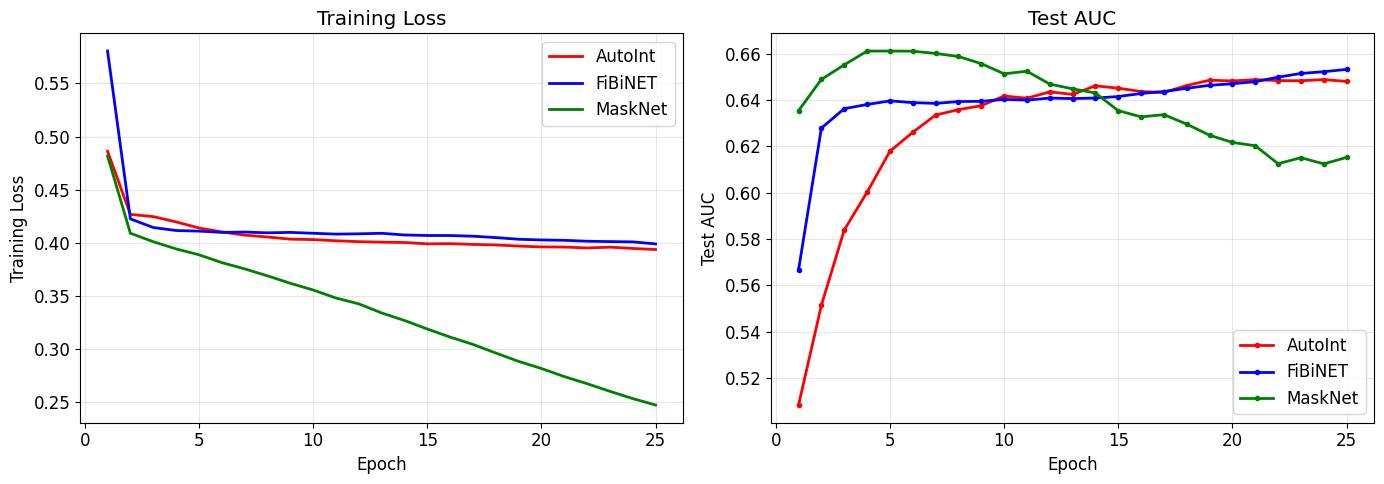

AutoInt: best AUC = 0.6488
FiBiNET: best AUC = 0.6532
MaskNet: best AUC = 0.6612


In [7]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 26)
models_info = [
    ('AutoInt', autoint_hist, 'r'),
    ('FiBiNET', fibinet_hist, 'b'),
    ('MaskNet', masknet_hist, 'g')
]

for name, hist, color in models_info:
    axes[0].plot(epochs, hist['train_loss'], f'{color}-', label=name, linewidth=2)
    axes[1].plot(epochs, hist['test_auc'], f'{color}-o', label=name, linewidth=2, markersize=3)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Test AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for name, hist, _ in models_info:
    print(f"{name}: best AUC = {max(hist['test_auc']):.4f}")

## 7. Visualizing AutoInt Attention Patterns

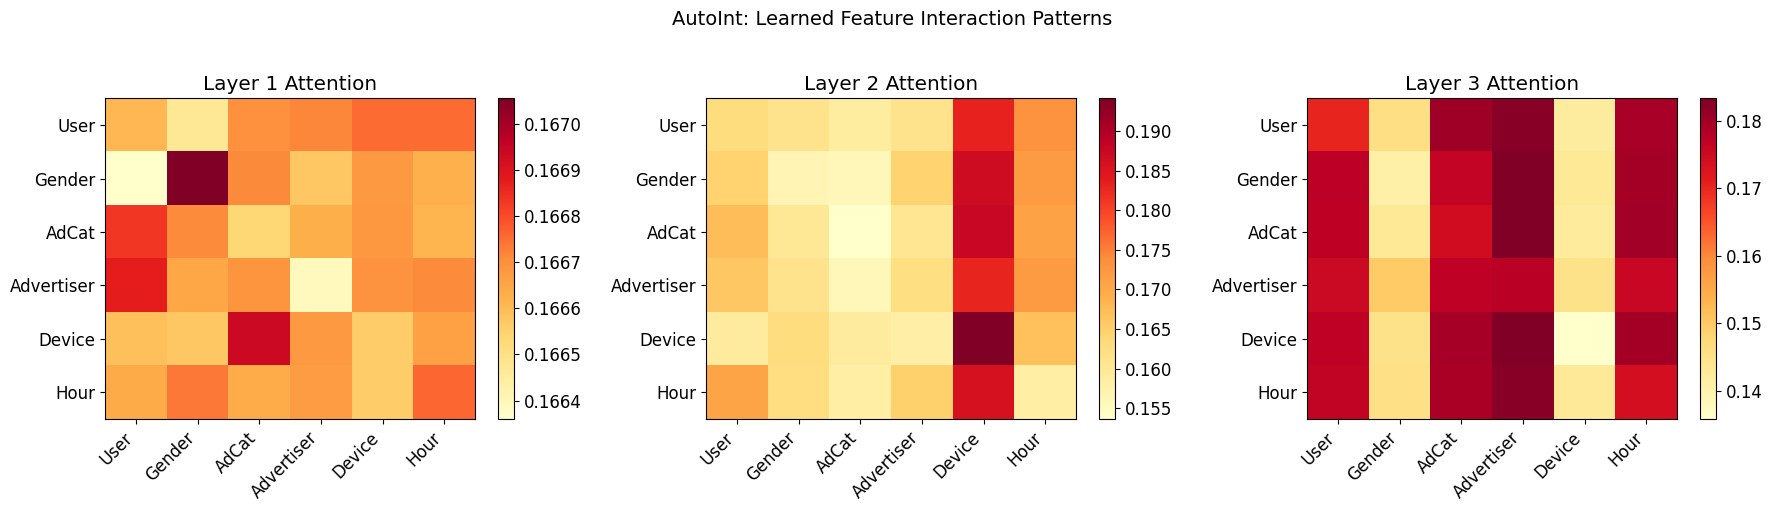

In [8]:
# Visualize attention maps from AutoInt
autoint.eval()
with torch.no_grad():
    _ = autoint(torch.LongTensor(X_test[:100]))
    # Get attention maps from last layer
    attn_maps = autoint.attention_maps  # list of (batch, n_heads, n_fields, n_fields)

field_names = ['User', 'Gender', 'AdCat', 'Advertiser', 'Device', 'Hour']

fig, axes = plt.subplots(1, len(attn_maps), figsize=(6 * len(attn_maps), 5))
if len(attn_maps) == 1:
    axes = [axes]

for layer_idx, attn in enumerate(attn_maps):
    # Average over batch and heads
    avg_attn = attn[:100].mean(dim=0).mean(dim=0).numpy()  # (n_fields, n_fields)
    
    im = axes[layer_idx].imshow(avg_attn, cmap='YlOrRd', aspect='auto')
    axes[layer_idx].set_xticks(range(n_fields))
    axes[layer_idx].set_yticks(range(n_fields))
    axes[layer_idx].set_xticklabels(field_names, rotation=45, ha='right')
    axes[layer_idx].set_yticklabels(field_names)
    axes[layer_idx].set_title(f'Layer {layer_idx + 1} Attention')
    plt.colorbar(im, ax=axes[layer_idx])

plt.suptitle('AutoInt: Learned Feature Interaction Patterns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. FiBiNET Feature Importance via SENET

/var/folders/fm/hwpyrzvx207290wd3x3n9zgh0000gn/T/ipykernel_78428/1145507337.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([importance[:, i] for i in range(n_fields)],


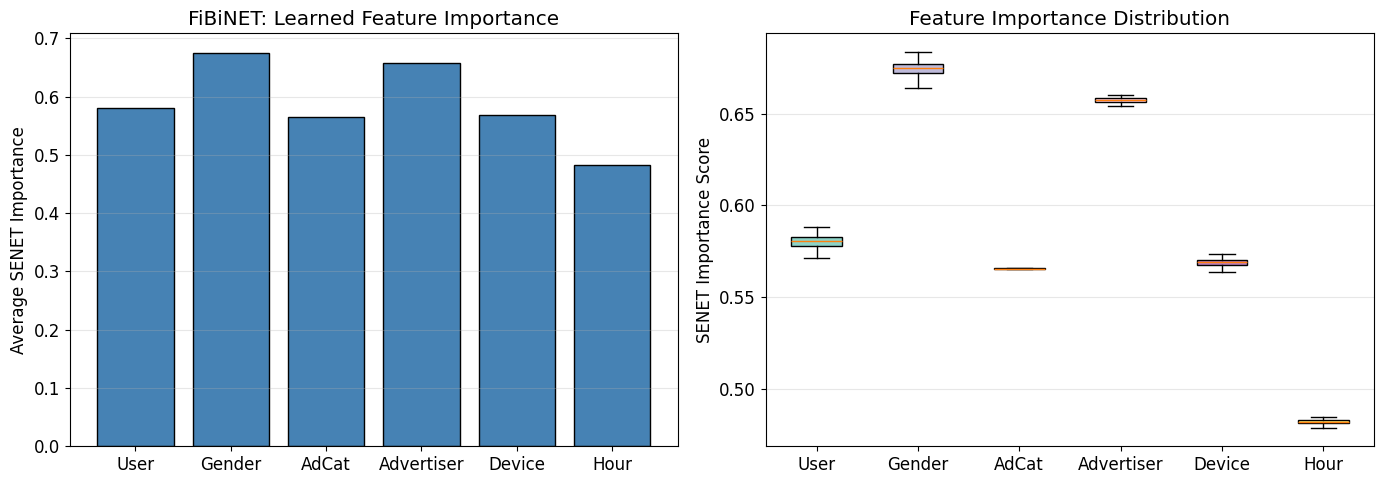

In [9]:
# Analyze SENET feature importance scores
fibinet.eval()
with torch.no_grad():
    tx = torch.LongTensor(X_test[:500])
    embed = fibinet.embedding(tx)  # (500, n_fields, d)
    
    # Get SE weights
    squeezed = embed.mean(dim=-1)  # (500, n_fields)
    # Access the SENET
    importance = fibinet.senet.se(squeezed).numpy()  # (500, n_fields)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average importance
avg_importance = importance.mean(axis=0)
axes[0].bar(field_names, avg_importance, color='steelblue', edgecolor='black')
axes[0].set_ylabel('Average SENET Importance')
axes[0].set_title('FiBiNET: Learned Feature Importance')
axes[0].grid(True, alpha=0.3, axis='y')

# Importance distribution per field
bp = axes[1].boxplot([importance[:, i] for i in range(n_fields)],
                     labels=field_names, patch_artist=True)
colors_bp = plt.cm.Set3(np.linspace(0, 1, n_fields))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
axes[1].set_ylabel('SENET Importance Score')
axes[1].set_title('Feature Importance Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Automated Feature Crossing (NAS for CTR)

Recent work applies **Neural Architecture Search** to automatically discover optimal feature interaction structures:

- **AutoCross** (Luo et al., 2019): search for effective cross features
- **AutoFIS** (Liu et al., 2020): automatically select important feature interactions
- **PROFIT** (2021): progressive feature interaction search

The idea: instead of manually choosing which features to cross or which interaction model to use, let the algorithm search for the optimal interaction structure.

> **Pro Tip:** NAS-based methods are expensive to train but can find architectures that outperform hand-designed models. In practice, the searched architecture is used as a fixed model for serving.

---
## Exercises

### Exercise 1: Implement AutoInt Self-Attention from Scratch

In [10]:
# Exercise 1: Implement the AutoInt attention mechanism without using nn.MultiheadAttention
# TODO: Write the Q, K, V projections manually
# TODO: Implement scaled dot-product attention
# TODO: Add residual connection and layer norm
# TODO: Verify it produces the same output shape as our AutoIntLayer

class ManualAutoIntLayer(nn.Module):
    def __init__(self, embed_dim, n_heads=2):
        super().__init__()
        # YOUR CODE HERE
        pass
    
    def forward(self, x):
        # YOUR CODE HERE
        pass

# YOUR CODE HERE

### Exercise 2: AutoInt Depth and Width Analysis

In [11]:
# Exercise 2: Ablation study on AutoInt architecture
# TODO: Vary n_layers in [1, 2, 3, 4, 5]
# TODO: Vary n_heads in [1, 2, 4]
# TODO: Create a heatmap of AUC for (n_layers, n_heads) combinations
# TODO: What's the best configuration? Is deeper always better?

# YOUR CODE HERE

### Exercise 3: Combine AutoInt with DNN

In [12]:
# Exercise 3: Create AutoInt + DNN (like DeepFM but with AutoInt instead of FM)
# TODO: Implement a model that combines:
#   - AutoInt for explicit feature interactions
#   - MLP for implicit high-order interactions
# TODO: Compare AutoInt-only vs DNN-only vs AutoInt+DNN

# YOUR CODE HERE

### Exercise 4: Model Efficiency Comparison

In [13]:
# Exercise 4: Compare models on efficiency (params, FLOPs, inference time)
# TODO: For each model (AutoInt, FiBiNET, MaskNet):
#   a) Count total parameters
#   b) Measure inference time for 1000 samples
#   c) Plot AUC vs params and AUC vs inference time
# TODO: Which model gives the best efficiency-accuracy tradeoff?

import time

# YOUR CODE HERE

## Summary

In this chapter, we covered:

1. **AutoInt** (Song et al., 2019): Multi-head self-attention for automatic feature interactions with interpretable attention patterns
2. **FiBiNET** (Huang et al., 2019): SENET for feature importance + bilinear interactions for richer pairwise modeling
3. **MaskNet** (Sina Weibo, 2021): Instance-guided feature masking for dynamic, input-dependent feature selection
4. **NAS for CTR**: Automated search for optimal feature interaction architectures

### Key Takeaways

- Self-attention naturally models arbitrary feature interactions with interpretable weights
- Feature importance weighting (SENET) helps focus on relevant features per instance
- Instance-guided masking makes feature interactions input-dependent
- There is no single best architecture -- the choice depends on data characteristics and efficiency requirements

### What's Next

In Chapter 2.8, we'll address **calibration and bias** in CTR prediction -- position bias, selection bias, and how to correct for them.